
--- Starting Classifier Training on CPU ---
Epoch 1/10 - Loss: 0.7079 | Acc: 59.06%
Epoch 2/10 - Loss: 0.4803 | Acc: 80.15%
Epoch 3/10 - Loss: 0.4780 | Acc: 83.72%
Epoch 4/10 - Loss: 0.4205 | Acc: 82.12%
Epoch 5/10 - Loss: 0.3685 | Acc: 86.19%
Epoch 6/10 - Loss: 0.3659 | Acc: 85.45%
Epoch 7/10 - Loss: 0.2986 | Acc: 88.78%
Epoch 8/10 - Loss: 0.2861 | Acc: 89.27%
Epoch 9/10 - Loss: 0.2484 | Acc: 89.64%
Epoch 10/10 - Loss: 0.2187 | Acc: 91.62%
Classifier Training Complete!

STARTING RL TRAINING: 5x5 GRID
Size  5 | Ep 100 | Avg R:   32.1 | Avg Cov:  63.4% | Sharks: 4/5


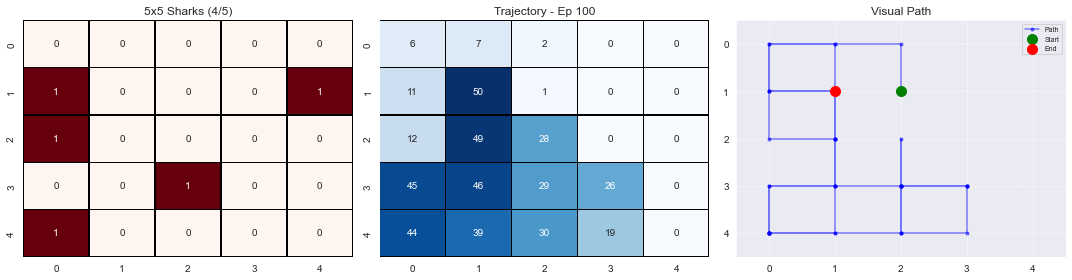

Size  5 | Ep 200 | Avg R:   40.3 | Avg Cov:  69.8% | Sharks: 5/5


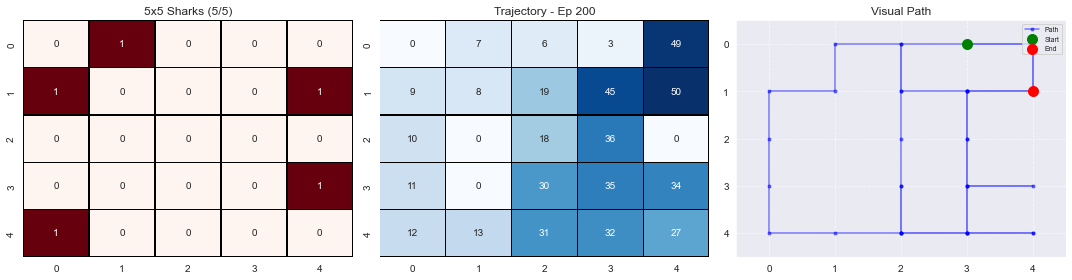

Size  5 | Ep 300 | Avg R:   42.5 | Avg Cov:  68.8% | Sharks: 7/7


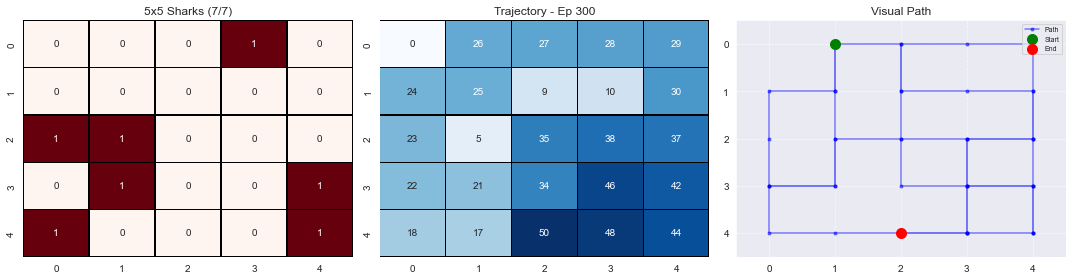

Size  5 | Ep 400 | Avg R:   50.5 | Avg Cov:  72.7% | Sharks: 4/5


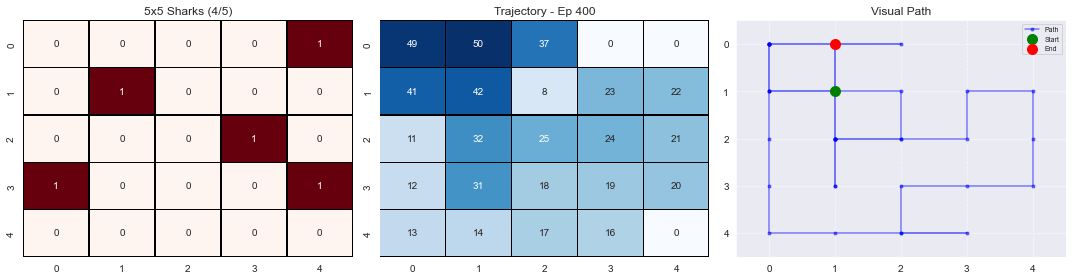

Size  5 | Ep 500 | Avg R:   47.6 | Avg Cov:  73.1% | Sharks: 6/7


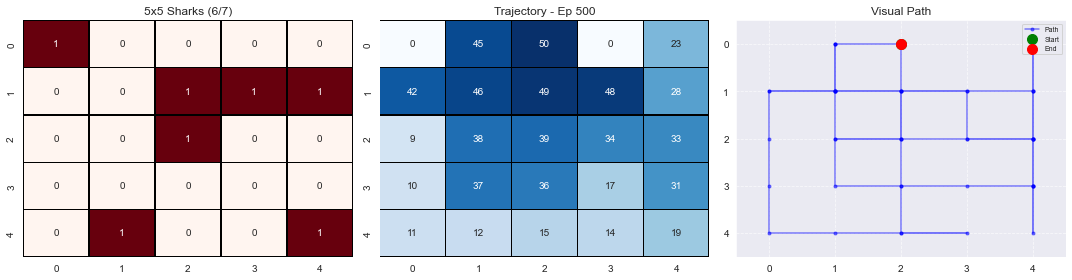

Size  5 | Ep 600 | Avg R:   53.1 | Avg Cov:  76.0% | Sharks: 4/7


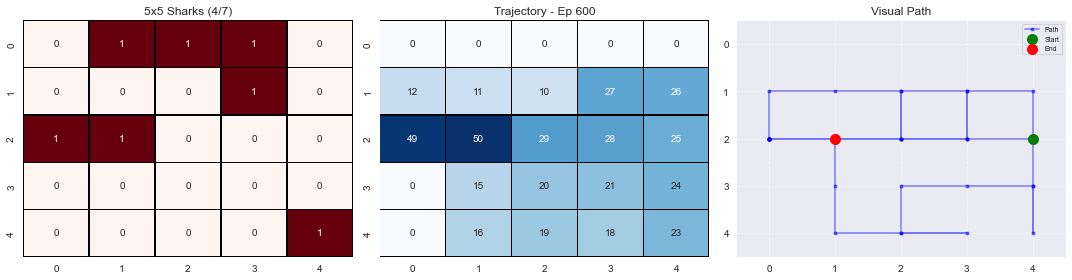

Size  5 | Ep 700 | Avg R:   54.5 | Avg Cov:  76.8% | Sharks: 3/9


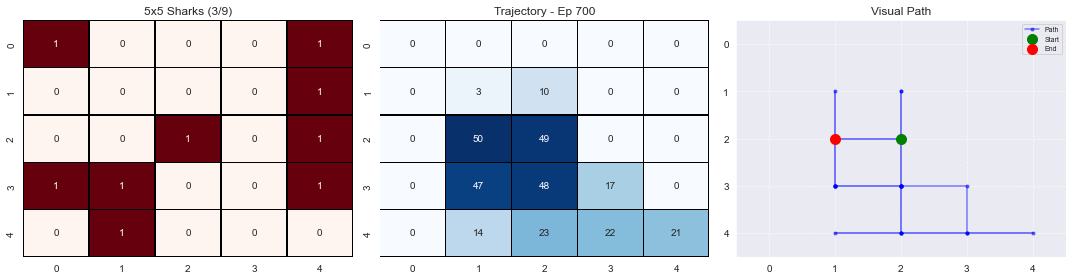

Size  5 | Ep 800 | Avg R:   55.3 | Avg Cov:  76.6% | Sharks: 7/8


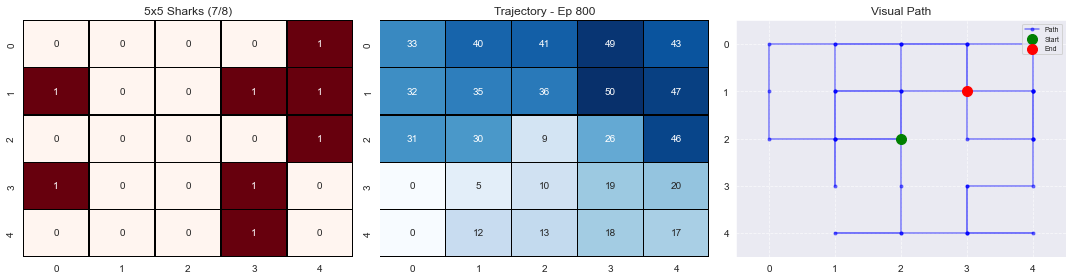


STARTING RL TRAINING: 7x7 GRID
Size  7 | Ep 100 | Avg R:   64.1 | Avg Cov:  60.7% | Sharks: 10/13


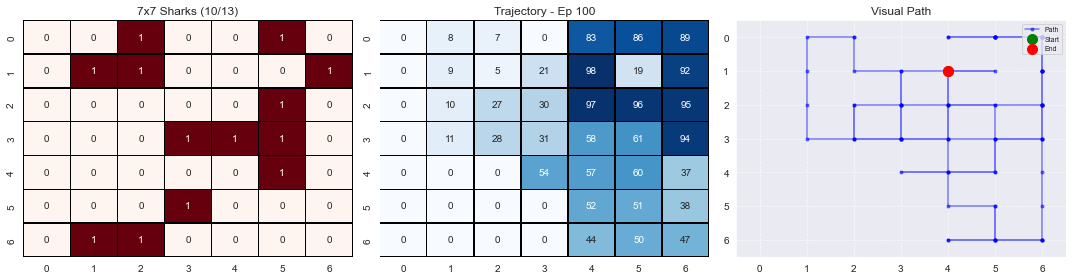

Size  7 | Ep 200 | Avg R:   60.1 | Avg Cov:  58.1% | Sharks: 8/17


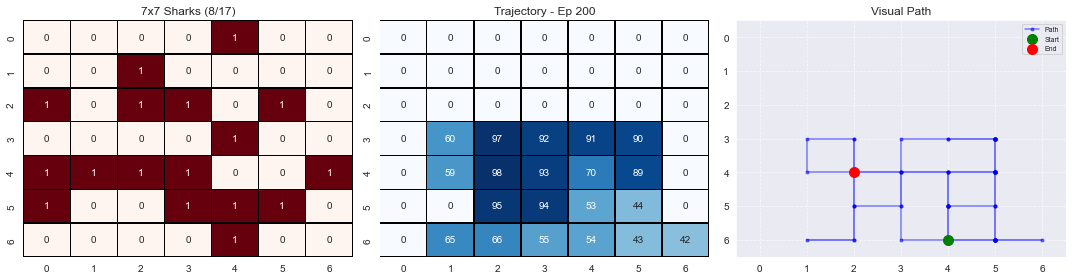

Size  7 | Ep 300 | Avg R:   77.2 | Avg Cov:  64.3% | Sharks: 13/19


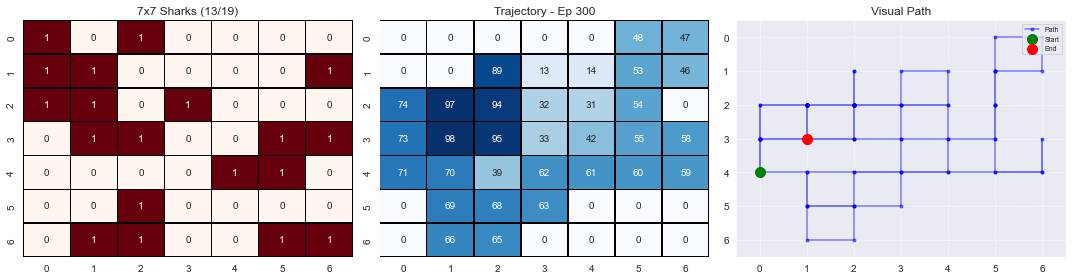

Size  7 | Ep 400 | Avg R:   67.8 | Avg Cov:  61.5% | Sharks: 16/18


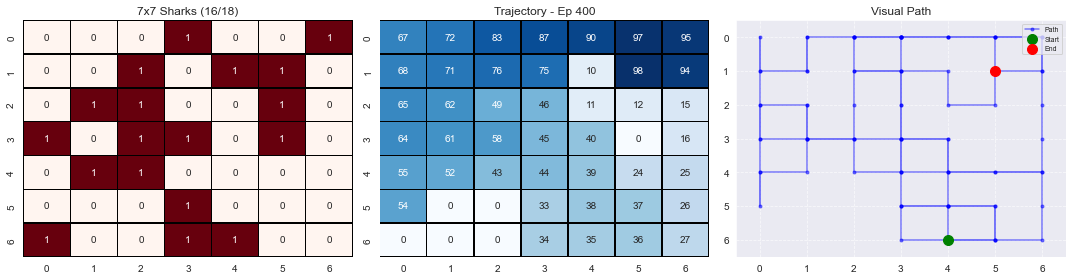

Size  7 | Ep 500 | Avg R:   70.3 | Avg Cov:  62.4% | Sharks: 5/13


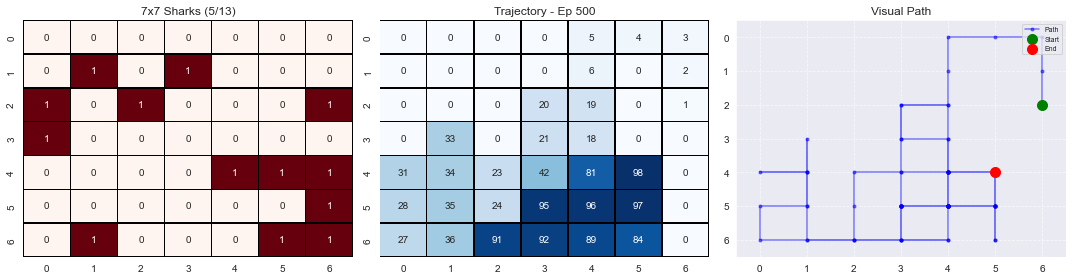

Size  7 | Ep 600 | Avg R:   68.7 | Avg Cov:  62.7% | Sharks: 10/13


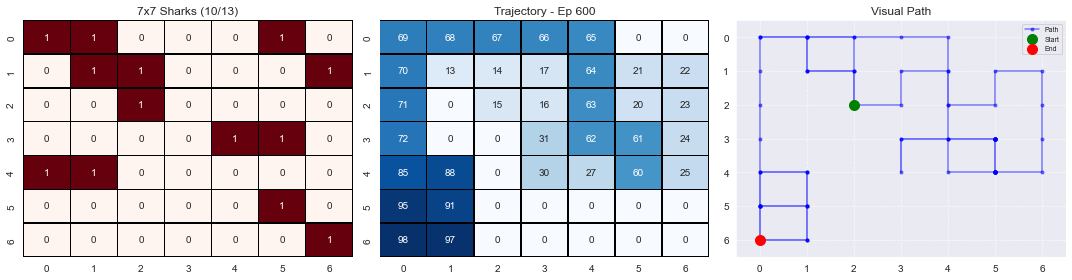

Size  7 | Ep 700 | Avg R:   71.7 | Avg Cov:  63.7% | Sharks: 5/10


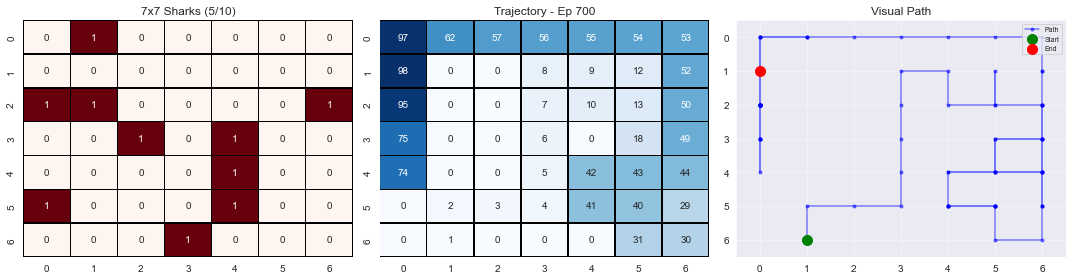

Size  7 | Ep 800 | Avg R:   73.9 | Avg Cov:  65.0% | Sharks: 13/16


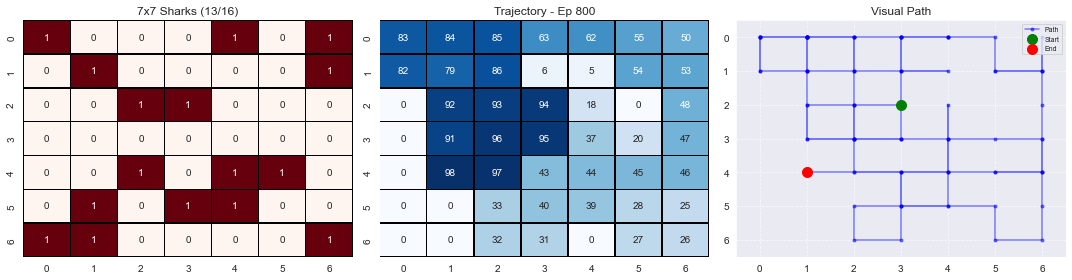


STARTING RL TRAINING: 10x10 GRID
Size 10 | Ep 100 | Avg R:   81.8 | Avg Cov:  51.9% | Sharks: 14/31


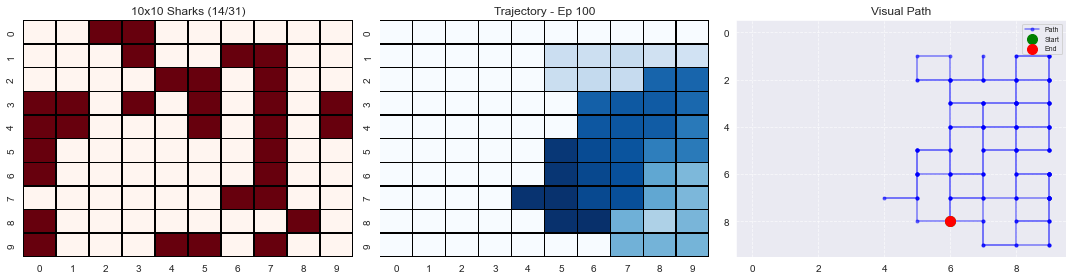

Size 10 | Ep 200 | Avg R:  100.8 | Avg Cov:  54.1% | Sharks: 13/38


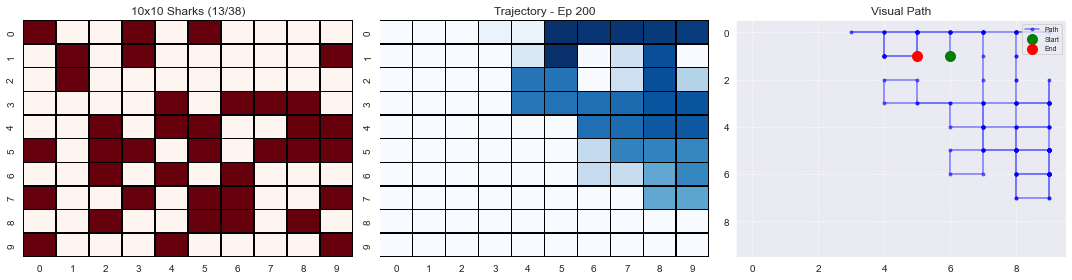

Size 10 | Ep 300 | Avg R:   94.4 | Avg Cov:  53.6% | Sharks: 12/25


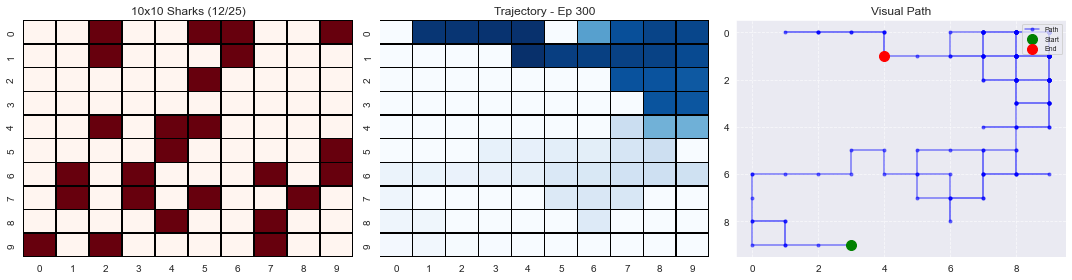

Size 10 | Ep 400 | Avg R:  101.1 | Avg Cov:  54.2% | Sharks: 17/30


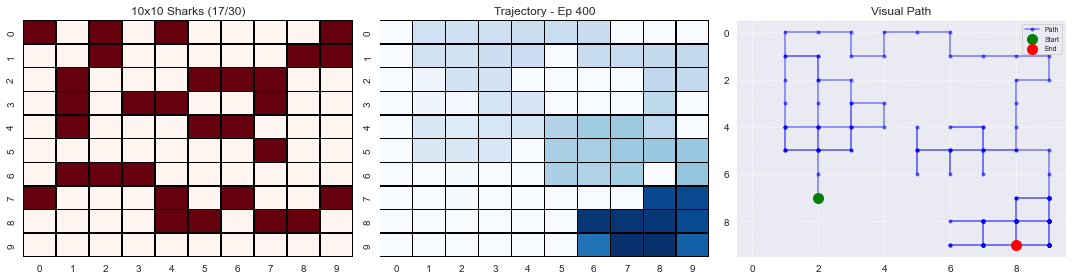

Size 10 | Ep 500 | Avg R:   98.7 | Avg Cov:  54.2% | Sharks: 11/21


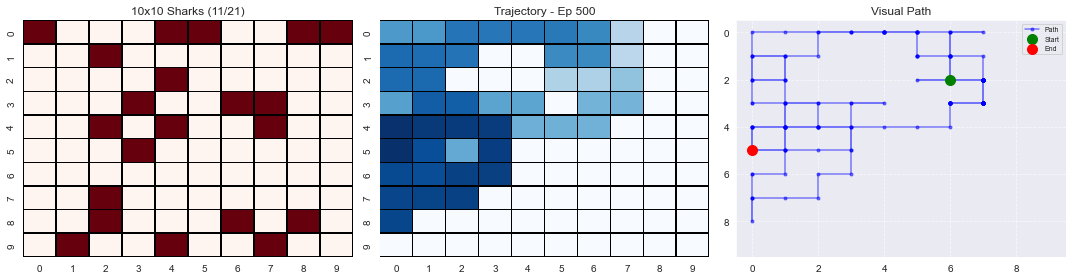

Size 10 | Ep 600 | Avg R:  117.6 | Avg Cov:  57.2% | Sharks: 24/36


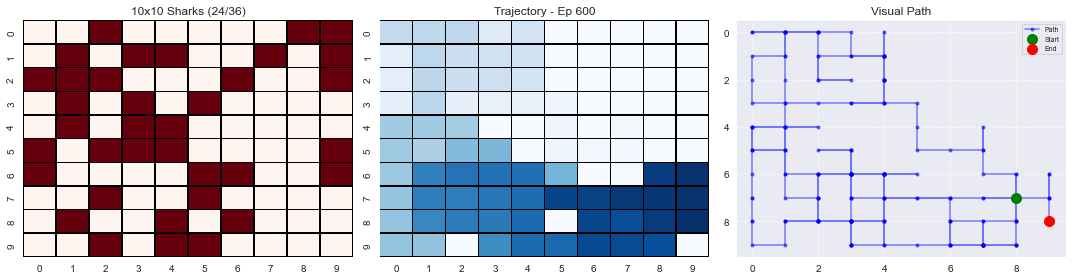

Size 10 | Ep 700 | Avg R:  103.7 | Avg Cov:  55.2% | Sharks: 15/27


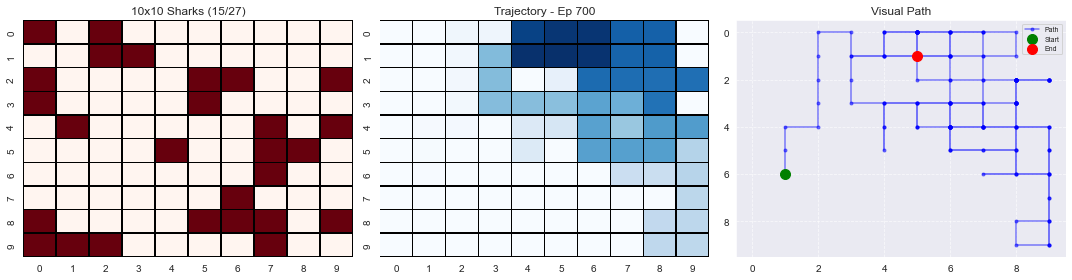

Size 10 | Ep 800 | Avg R:  136.0 | Avg Cov:  60.6% | Sharks: 17/27


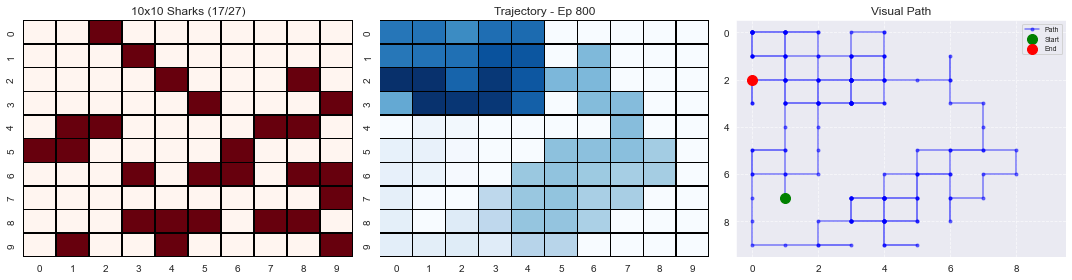


Training Complete! Generating Final Reports...


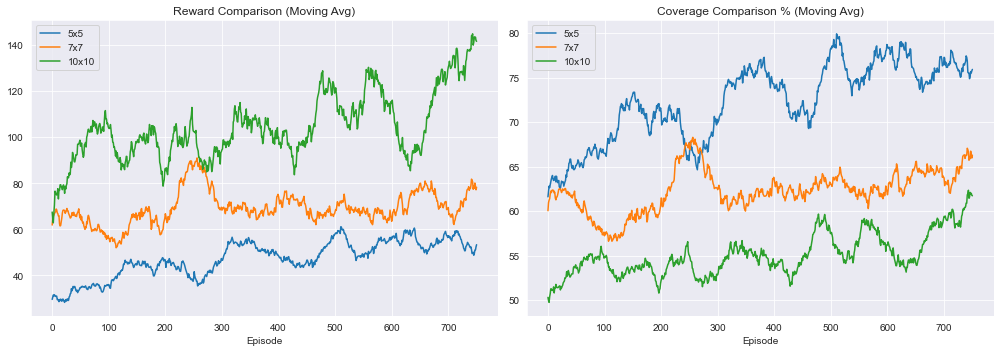


GRID SIZE    | AVG REWARD   | AVG COV %    | SHARK RATIO 
-----------------------------------------------------------------
5            | 55.3         | 76.6         | 5.8/7.8     
7            | 73.9         | 65.0         | 9.3/14.0    
10           | 136.0        | 60.6         | 17.9/29.8   


In [4]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# CNN Classifier
class SharkClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128*16*16, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(data_dir="data", epochs=10, batch_size=32, lr=1e-3, device="cpu"):
    print("---------------------------------------------------------")
    print(f"Starting Classifier Training... \n")
    print("---------------------------------------------------------")
    transform = transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor()
    ])
    try:
        dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    except FileNotFoundError:
        print(f"Error: Ensure '{data_dir}' folder exists.")
        return None, None, None

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = SharkClassifier(num_classes=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        print(f"--- Finished Epoch {epoch+1} of {epochs} ---")
        print(f" > Average Loss: {running_loss/len(loader):.4f}")
        print(f" > Accuracy so far: {100*correct/total:.1f}%")

    print("Classifier Training Complete!\n")
    return model, dataset.classes, dataset

# Environment
class GridSharkEnv:
    def __init__(self, grid_size=5, episode_len=None, shark_prob=0.3,
                 classifier=None, classifier_classes=None, example_imgs=None,
                 device="cpu", seed=42):
        self.grid_size = grid_size
        self.episode_len = episode_len or (grid_size**2 * 2)
        self.shark_prob = shark_prob
        self.classifier = classifier.to(device)
        self.classifier.eval() 
        self.classes = classifier_classes
        self.shark_idx = self.classes.index("sharks")
        self.example_imgs = example_imgs 
        self.device = device
        self.rng = random.Random(seed)
        self.reset()

    def reset(self):
        self.cell_class = {}
        self.perceived_grid = {} 
        self.total_sharks = 0
        
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                is_shark = self.rng.random() < self.shark_prob
                gt_label = "sharks" if is_shark else "underwater"
                self.cell_class[(i, j)] = gt_label
                if is_shark: self.total_sharks += 1
                
                img = self.example_imgs[gt_label].to(self.device)
                with torch.no_grad():
                    output = self.classifier(img)
                    pred_idx = torch.argmax(output, 1).item()
                    self.perceived_grid[(i, j)] = self.classes[pred_idx]

        self.shark_map = np.array([[1 if self.cell_class[(i,j)] == "sharks" else 0 
                                   for j in range(self.grid_size)] for i in range(self.grid_size)])
        
        self.pos = (self.rng.randrange(self.grid_size), self.rng.randrange(self.grid_size))
        self.visited = np.zeros((self.grid_size, self.grid_size), dtype=np.uint8)
        self.visited[self.pos] = 1
        self.sharks_found = 1 if self.cell_class[self.pos] == "sharks" else 0
        self.steps = 0
        return self._get_obs()

    def _get_obs(self):
        x, y = self.pos
        unvisited_count = self.grid_size**2 - np.sum(self.visited)
        return {"x": x, "y": y, "rem": int(unvisited_count)}

    def state_id(self, obs):
        pos_idx = obs["x"] * self.grid_size + obs["y"]
        return pos_idx + (obs["rem"] * (self.grid_size**2))

    # Steps the "drone" takes and also rewards attributed
    def step(self, action):
        x, y = self.pos
        if action == 0: x = max(0, x-1) 
        elif action == 1: x = min(self.grid_size-1, x+1)
        elif action == 2: y = max(0, y-1) 
        elif action == 3: y = min(self.grid_size-1, y+1)
        
        is_new = (self.visited[(x, y)] == 0)
        self.pos = (x, y)
        self.visited[self.pos] = 1
        self.steps += 1

        pred = self.perceived_grid[self.pos]
        gt = self.cell_class[self.pos]

        reward = -0.1
        if is_new:
            reward += 2.0 
            if gt == "sharks":
                if pred == "sharks":
                    self.sharks_found += 1
                    reward += 10.0
                else:
                    reward -= 2.0 
        else:
            reward -= 1.0 

        done = self.steps >= self.episode_len or np.all(self.visited == 1)
        return self._get_obs(), reward, done, {"sharks_found": self.sharks_found, "total_sharks": self.total_sharks}


# Q-table implementation
class QLearningAgent:
    def __init__(self, n_states, n_actions, decay_factor=0.9998):
        self.q_table = np.zeros((n_states, n_actions))
        self.lr, self.gamma, self.epsilon = 0.1, 0.9, 1.0
        self.eps_min = 0.05
        self.eps_decay = decay_factor 

    def act(self, state):
        if random.random() < self.epsilon: return random.randint(0, 3)
        return int(np.argmax(self.q_table[state]))

    def learn(self, s, a, r, s_next, done):
        target = r + (self.gamma * np.max(self.q_table[s_next]) if not done else 0)
        self.q_table[s, a] += self.lr * (target - self.q_table[s, a])
        if self.epsilon > self.eps_min: self.epsilon *= self.eps_decay


# Plot of the trajectory heatmap and also where the sharks are located for visual analysis
def plot_dashboard(shark_map, traj, episode, sharks_found, total_sharks, grid_size=5):
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    sns.heatmap(shark_map, cmap="Reds", annot=(grid_size <= 7), cbar=False, linewidths=0.5, linecolor='black')
    plt.title(f"{grid_size}x{grid_size} Sharks ({sharks_found}/{total_sharks})")

    plt.subplot(1, 3, 2)
    grid = np.zeros((grid_size, grid_size))
    for step, (x, y) in enumerate(traj):
        grid[x, y] = step + 1
    sns.heatmap(grid, cmap="Blues", annot=(grid_size <= 7), fmt=".0f", linewidths=0.5, linecolor='black', cbar=False)
    plt.title(f"Trajectory - Ep {episode}")

    plt.subplot(1, 3, 3)
    traj_x, traj_y = zip(*traj)
    plt.plot(traj_y, traj_x, marker='o', color='blue', alpha=0.5, markersize=3, label='Path')
    plt.scatter(traj_y[0], traj_x[0], color='green', s=100, label='Start', zorder=5) 
    plt.scatter(traj_y[-1], traj_x[-1], color='red', s=100, label='End', zorder=5)   
    plt.xlim(-0.5, grid_size - 0.5); plt.ylim(grid_size - 0.5, -0.5) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.title(f"Visual Path")
    plt.legend(loc='upper right', fontsize='x-small')

    plt.tight_layout()
    plt.show()
    
# Plot of the graphs containing 5x5 & 7x7 & 10x10 grids. We are here comparing both the rewards given and the coverage comparison
def plot_final_trends(all_results):
    plt.figure(figsize=(14, 5))
    window = 50
    
    plt.subplot(1, 2, 1)
    for size, data in all_results.items():
        rewards = data["reward"]
        avg_r = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(avg_r, label=f"{size}x{size}")
    plt.title("Reward Comparison"); plt.xlabel("Episode"); plt.legend()

    plt.subplot(1, 2, 2)
    for size, data in all_results.items():
        cov = data["coverage"]
        avg_c = np.convolve(cov, np.ones(window)/window, mode='valid')
        plt.plot(avg_c, label=f"{size}x{size}")
    plt.title("Coverage Comparison %"); plt.xlabel("Episode"); plt.legend()
    
    plt.tight_layout()
    plt.show()
    
# A table comparing the results between the grids
def print_comparison_table(all_results):
    print("\n" + "="*65)
    print(f"{'GRID SIZE':<12} | {'AVG REWARD':<12} | {'AVG COV %':<12} | {'SHARK RATIO':<12}")
    print("-" * 65)
    
    for size, data in all_results.items():
        # Look at the last 100 episodes for final performance
        final_r = np.mean(data['reward'][-100:])
        final_c = np.mean(data['coverage'][-100:])
        
        # Calculate average sharks found vs average total sharks
        avg_found = np.mean(data['sharks_found'][-100:])
        avg_total = np.mean(data['sharks_total'][-100:])
        shark_ratio = f"{avg_found:.1f}/{avg_total:.1f}"
        
        print(f"{size:<12} | {final_r:<12.1f} | {final_c:<12.1f} | {shark_ratio:<12}")
    print("="*65 + "\n")


# Main function
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, classes, dataset = train_classifier(device=device)

    if model:
        # Pre-extract one representative image per class for the CNN "sensor"
        example_imgs = {
            n: next(img for img, l in dataset if dataset.classes[l] == n).unsqueeze(0).to(device) 
            for n in classes
        }
        
        # Experiment Parameters
        grid_sizes = [5, 7, 10]
        all_results = {}
        total_episodes = 800

        for size in grid_sizes:
            print(f"\n" + "="*50)
            print(f"STARTING RL TRAINING: {size}x{size} GRID")
            print("="*50)
            
            # Initialize Environment for specific size
            env = GridSharkEnv(
                grid_size=size, 
                classifier=model, 
                classifier_classes=classes, 
                example_imgs=example_imgs, 
                device=device
            )
            
            # Calculate State Space
            n_states = (size**2) * (size**2 + 1)
            
            # Adjust decay since larger grids need more exploration time
            decay = 0.9998 if size == 5 else (0.9999 if size == 7 else 0.99995)
            agent = QLearningAgent(n_states, 4, decay_factor=decay)
            
            hist = {"reward": [], "coverage": [], "sharks_found": [], "sharks_total": []}

            for ep in range(1, total_episodes + 1):
                obs = env.reset()
                s = env.state_id(obs)
                total_r, trajectory = 0, []
                
                while True:
                    trajectory.append((obs["x"], obs["y"]))
                    a = agent.act(s)
                    obs_next, r, done, info = env.step(a)
                    s_next = env.state_id(obs_next)
                    
                    agent.learn(s, a, r, s_next, done)
                    
                    s, obs, total_r = s_next, obs_next, total_r + r
                    if done: break

                hist["reward"].append(total_r)
                hist["coverage"].append((np.sum(env.visited) / (size**2)) * 100)
                hist["sharks_found"].append(info['sharks_found'])
                hist["sharks_total"].append(info['total_sharks'])

                if ep % 100 == 0:
                    avg_reward = np.mean(hist['reward'][-100:])
                    avg_cov = np.mean(hist['coverage'][-100:])
                    
                    print(f"Size {size:2d} | Ep {ep:3d} | Avg R: {avg_reward:6.1f} | "
                          f"Avg Cov: {avg_cov:5.1f}% | "
                          f"Sharks: {info['sharks_found']}/{info['total_sharks']}")
                    
                    plot_dashboard(env.shark_map, trajectory, ep, 
                                   info['sharks_found'], info['total_sharks'], 
                                   grid_size=size)

            all_results[size] = hist

        print("\nTraining Complete! Final Reports:")
        
        plot_final_trends(all_results)
        
        print_comparison_table(all_results)


--- Starting Classifier Training on CPU ---
Epoch 1/10 - Loss: 0.6108 | Acc: 70.53%
Epoch 2/10 - Loss: 0.4544 | Acc: 81.75%
Epoch 3/10 - Loss: 0.3759 | Acc: 84.71%
Epoch 4/10 - Loss: 0.3314 | Acc: 86.19%
Epoch 5/10 - Loss: 0.3018 | Acc: 88.16%
Epoch 6/10 - Loss: 0.2759 | Acc: 88.78%
Epoch 7/10 - Loss: 0.2534 | Acc: 90.14%
Epoch 8/10 - Loss: 0.2477 | Acc: 90.01%
Epoch 9/10 - Loss: 0.2089 | Acc: 90.75%
Epoch 10/10 - Loss: 0.1693 | Acc: 93.59%
Classifier Training Complete!

Training Size: 5x5


C:\Users\HEI-Lab\PycharmProjects\Sharks_IA\.venv\lib\site-packages\ipykernel_launcher.py:108: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


Size 5 | Ep 100 | Avg R: 34.3


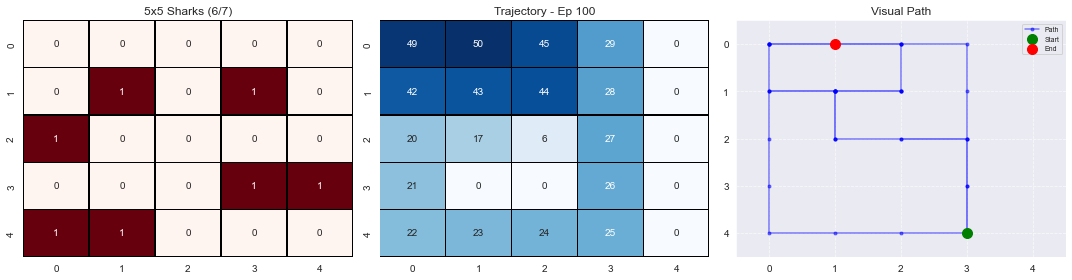

Size 5 | Ep 200 | Avg R: 34.0


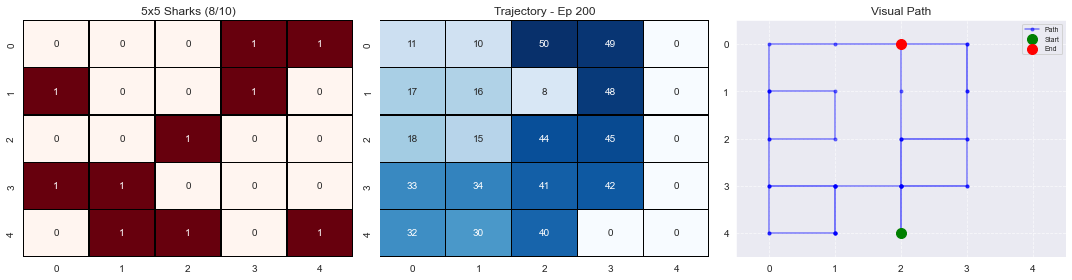

Size 5 | Ep 300 | Avg R: 37.1


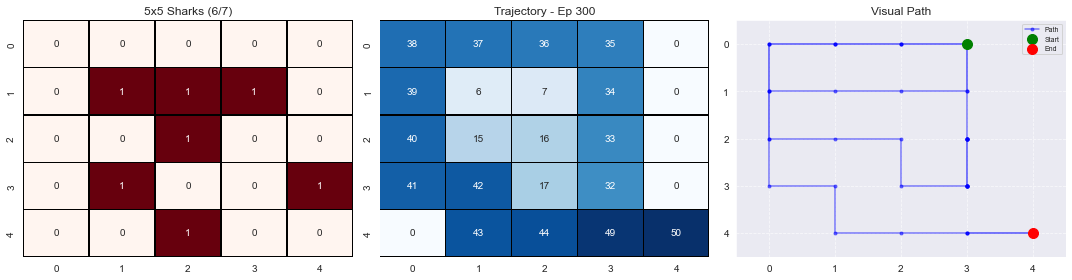

Size 5 | Ep 400 | Avg R: 47.7


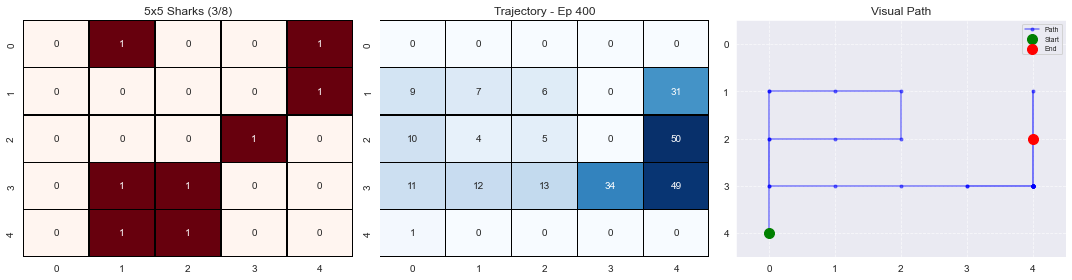

Size 5 | Ep 500 | Avg R: 61.2


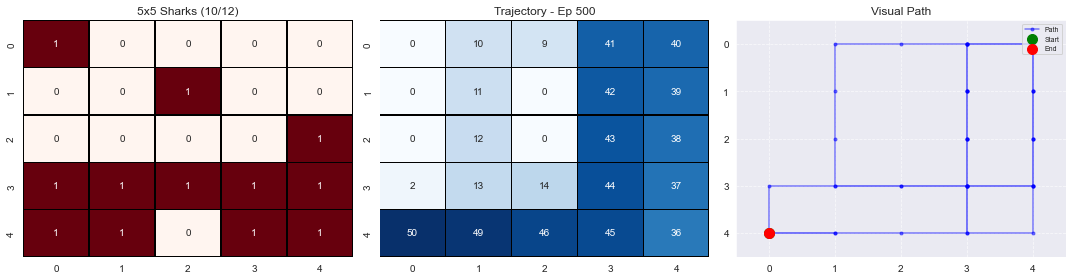

Size 5 | Ep 600 | Avg R: 60.9


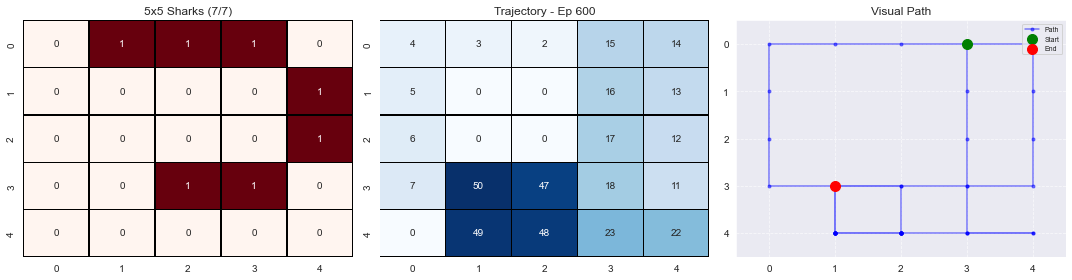

Size 5 | Ep 700 | Avg R: 59.7


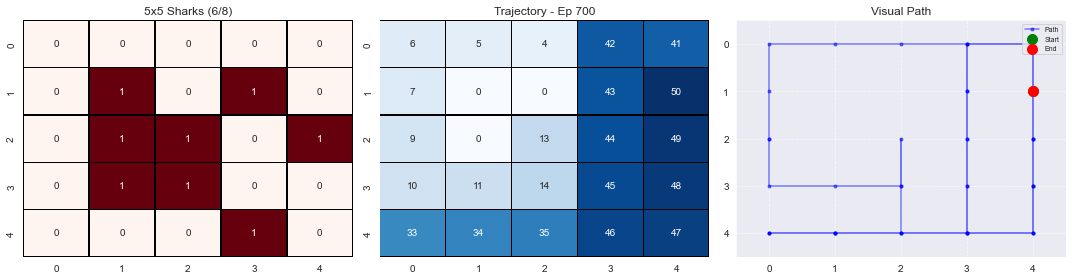

Size 5 | Ep 800 | Avg R: 62.3


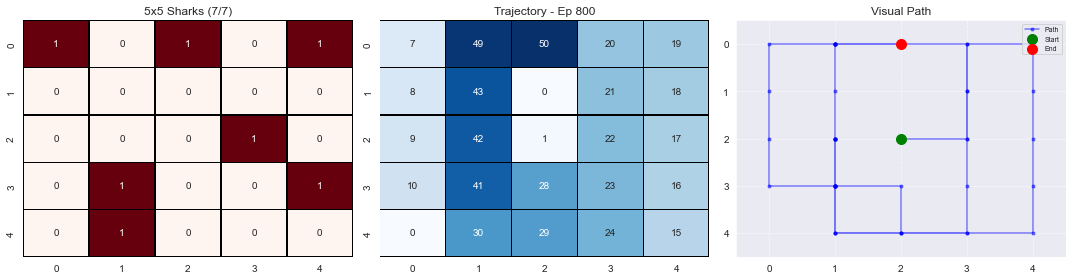


Training Size: 7x7
Size 7 | Ep 100 | Avg R: 56.6


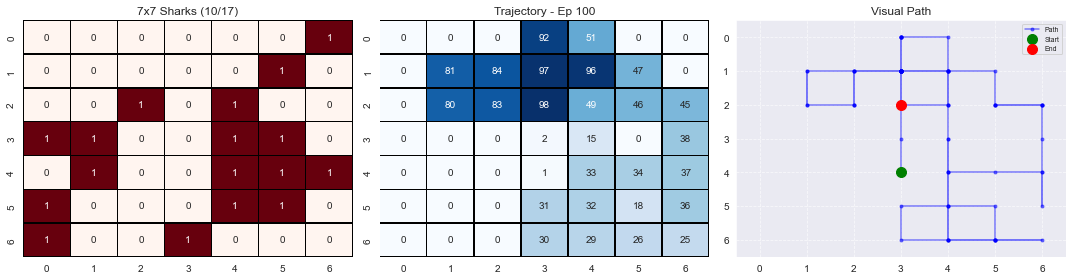

Size 7 | Ep 200 | Avg R: 78.7


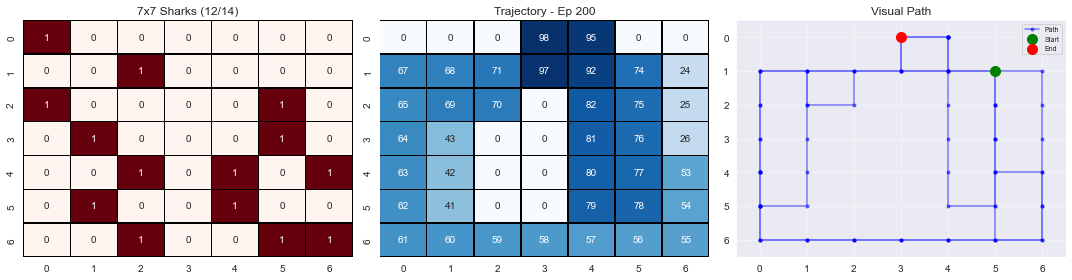

Size 7 | Ep 300 | Avg R: 92.8


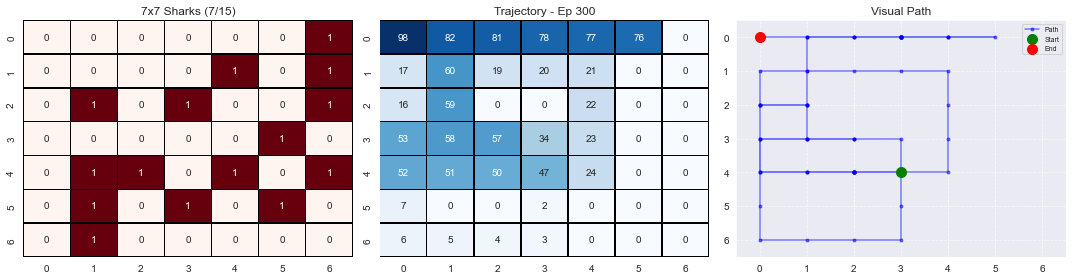

Size 7 | Ep 400 | Avg R: 88.1


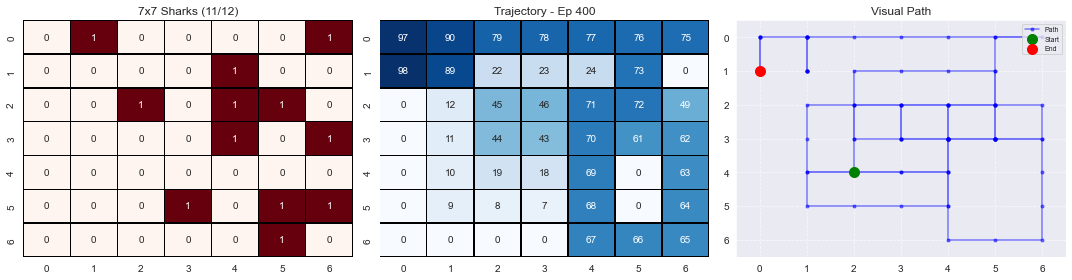

Size 7 | Ep 500 | Avg R: 93.5


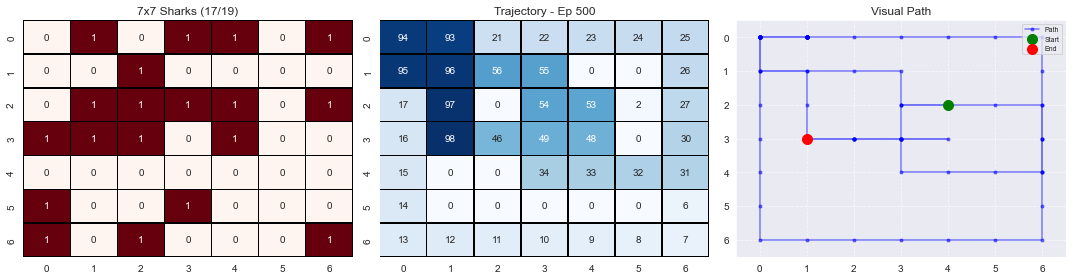

Size 7 | Ep 600 | Avg R: 92.4


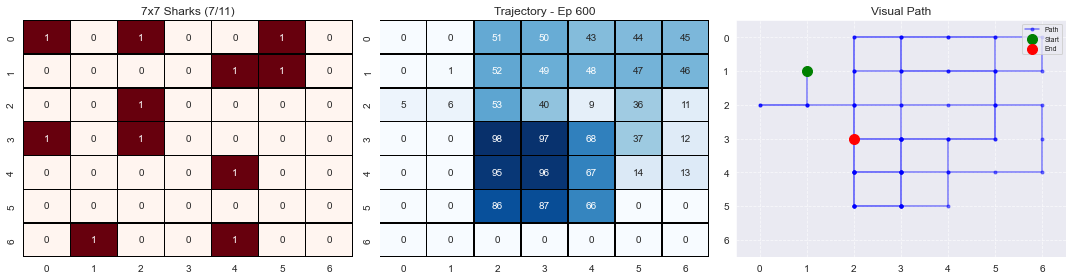

Size 7 | Ep 700 | Avg R: 105.2


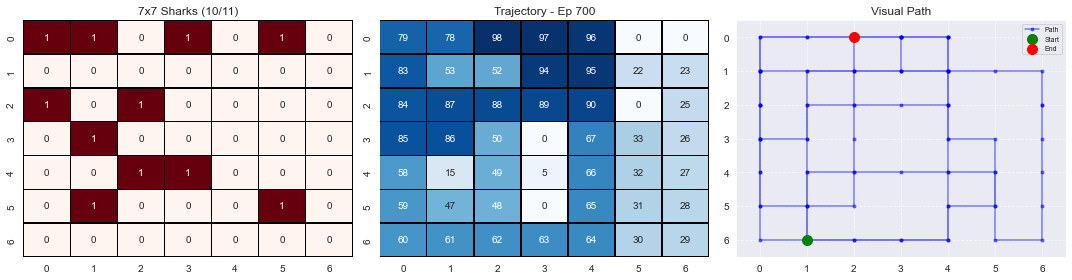

Size 7 | Ep 800 | Avg R: 128.3


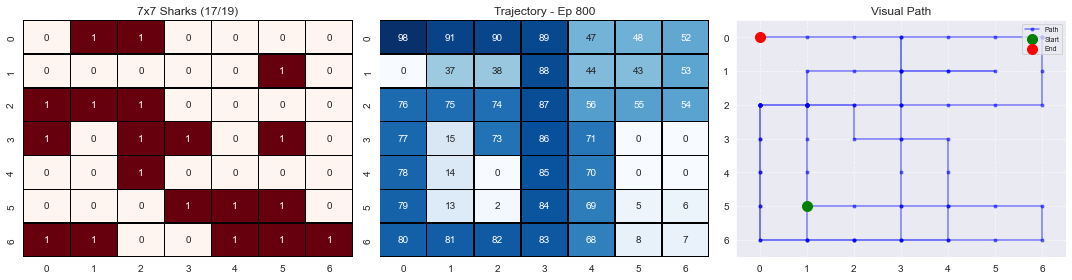


Training Size: 10x10
Size 10 | Ep 100 | Avg R: 63.9


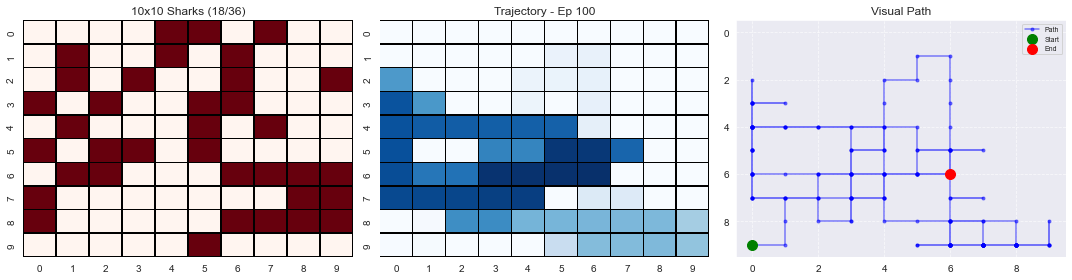

Size 10 | Ep 200 | Avg R: 45.8


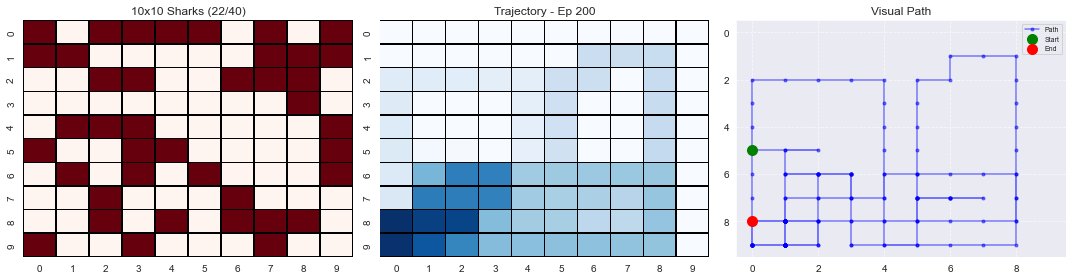

Size 10 | Ep 300 | Avg R: 102.7


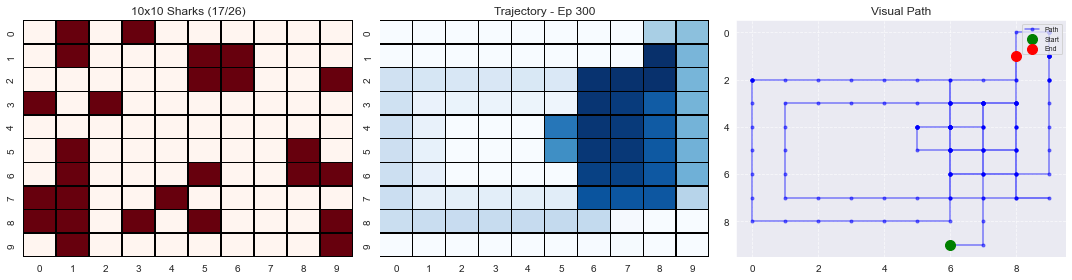

Size 10 | Ep 400 | Avg R: 99.2


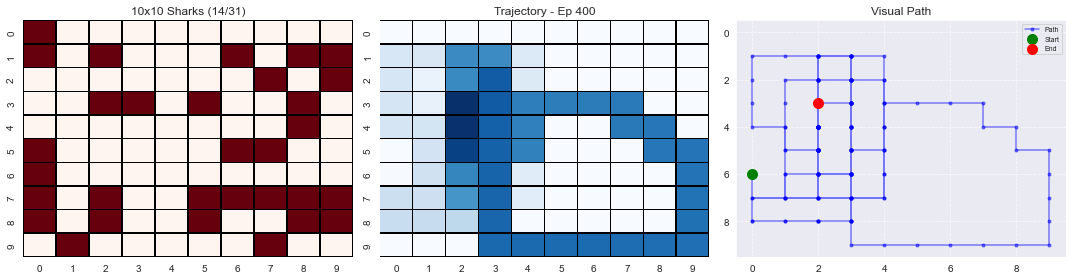

Size 10 | Ep 500 | Avg R: 146.3


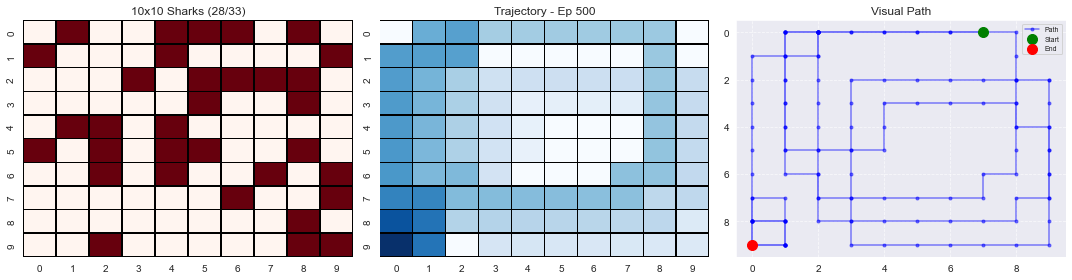

Size 10 | Ep 600 | Avg R: 210.3


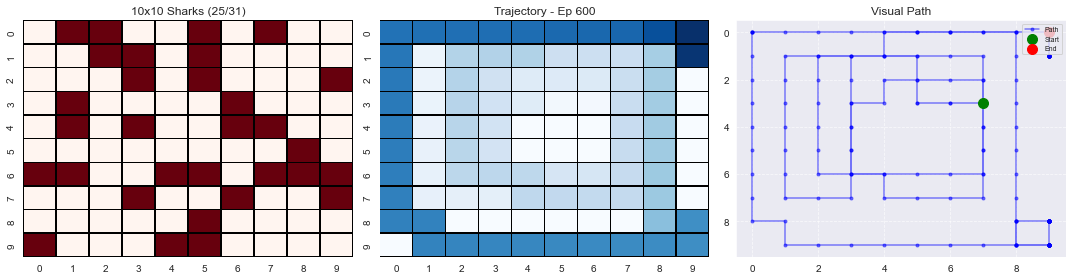

Size 10 | Ep 700 | Avg R: 197.1


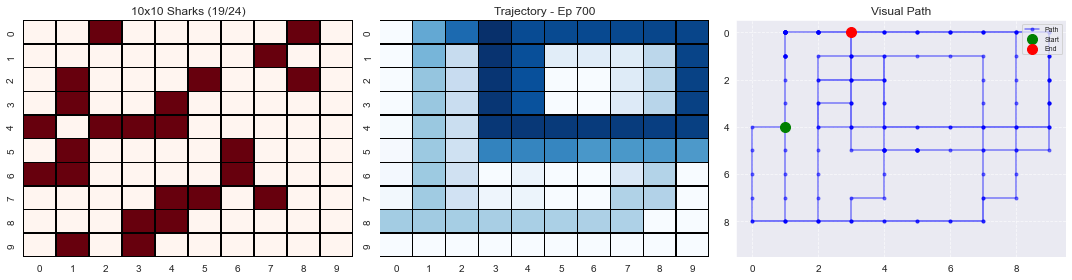

Size 10 | Ep 800 | Avg R: 208.1


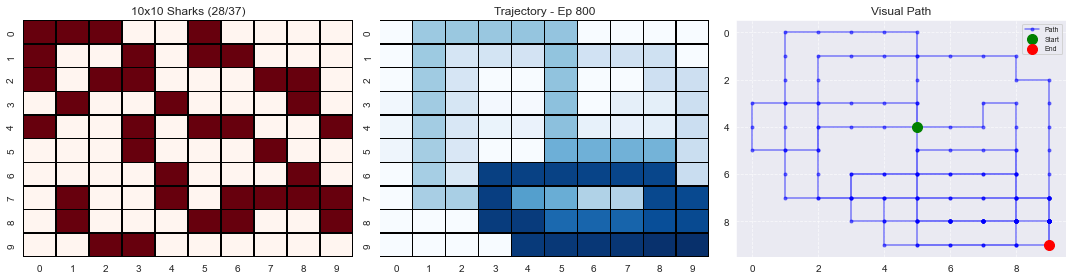

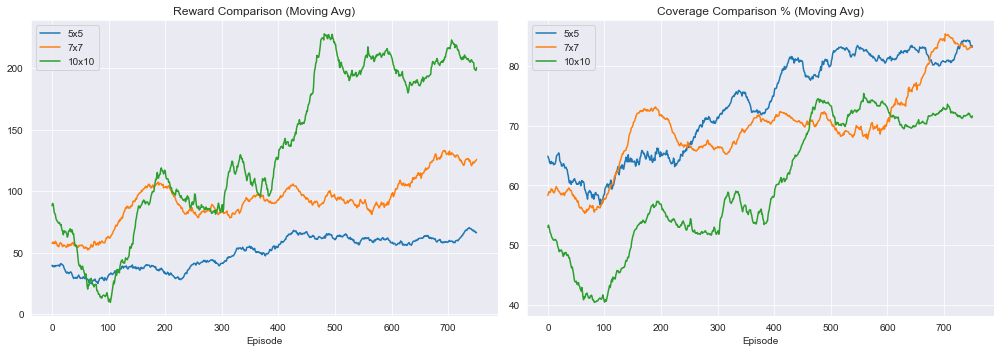


GRID SIZE    | AVG REWARD   | AVG COV %    | SHARK RATIO 
-----------------------------------------------------------------
5            | 62.3         | 82.0         | 6.2/7.4     
7            | 128.3        | 83.9         | 11.8/14.1   
10           | 208.1        | 72.2         | 21.8/30.4   


In [3]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

# CNN Classifier
class SharkClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128*16*16, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(data_dir="data", epochs=10, batch_size=32, lr=1e-3, device="cpu"):
    print("---------------------------------------------------------")
    print(f"Starting Classifier Training... \n")
    print("---------------------------------------------------------")
    transform = transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor()
    ])
    try:
        dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    except FileNotFoundError:
        print(f"Error: Ensure '{data_dir}' folder exists.")
        return None, None, None

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = SharkClassifier(num_classes=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        print(f"--- Finished Epoch {epoch+1} of {epochs} ---")
        print(f" > Average Loss: {running_loss/len(loader):.4f}")
        print(f" > Accuracy so far: {100*correct/total:.1f}%")

    print("Classifier Training Complete!\n")
    return model, dataset.classes, dataset

# DQN AGENT - Suggested by Professor when the plan was proposed
class QNetwork(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_actions)
        )
    def forward(self, x): return self.net(x)

class DQNAgent:
    def __init__(self, input_dim, n_actions, device="cpu", decay=0.9995):
        self.device, self.n_actions = device, n_actions
        self.policy_net = QNetwork(input_dim, n_actions).to(device)
        self.target_net = QNetwork(input_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.memory = deque(maxlen=10000)
        self.batch_size, self.gamma = 64, 0.95
        self.epsilon, self.eps_decay, self.eps_min = 1.0, decay, 0.05
        self.steps = 0

    def act(self, state):
        if random.random() < self.epsilon: return random.randint(0, self.n_actions-1)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.policy_net(state_t).argmax().item()

    def learn(self):
        if len(self.memory) < self.batch_size: return
        batch = random.sample(self.memory, self.batch_size)
        s, a, r, sn, d = zip(*batch)

        s, sn = torch.FloatTensor(np.array(s)).to(self.device), torch.FloatTensor(np.array(sn)).to(self.device)
        a, r, d = torch.LongTensor(a).to(self.device), torch.FloatTensor(r).to(self.device), torch.FloatTensor(d).to(self.device)

        q_values = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze()
        
        with torch.no_grad():
            next_q = self.target_net(sn).max(1)[0]
            targets = r + (self.gamma * next_q * (1 - d))

        loss = F.mse_loss(q_values, targets)
        
        self.optimizer.zero_grad()
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        
        self.optimizer.step()

        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        
        self.steps += 1
        if self.steps % 100 == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

# Environment
class GridSharkEnv:
    def __init__(self, grid_size=5, shark_prob=0.3, classifier=None, classes=None, imgs=None, device="cpu"):
        self.grid_size, self.shark_prob, self.device = grid_size, shark_prob, device
        self.classifier, self.classes, self.example_imgs = classifier, classes, imgs
        self.reset()

    def reset(self):
        self.cell_class, self.perceived_grid, self.total_sharks = {}, {}, 0
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                gt = "sharks" if random.random() < self.shark_prob else "underwater"
                self.cell_class[(i, j)] = gt
                if gt == "sharks": self.total_sharks += 1
                with torch.no_grad():
                    pred = self.classifier(self.example_imgs[gt]).argmax(1).item()
                    self.perceived_grid[(i, j)] = self.classes[pred]
        
        self.shark_map = np.array([[1 if self.cell_class[(i,j)] == "sharks" else 0 for j in range(self.grid_size)] for i in range(self.grid_size)])
        self.pos = (random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1))
        self.visited = np.zeros((self.grid_size, self.grid_size))
        self.visited[self.pos] = 1
        self.sharks_found = 1 if self.cell_class[self.pos] == "sharks" else 0
        self.steps = 0
        return self._get_obs()

    def _get_obs(self):
        return [self.pos[0]/self.grid_size, self.pos[1]/self.grid_size, (self.grid_size**2 - np.sum(self.visited))/self.grid_size**2]

    # Steps the "drone" takes and also rewards attributed
    def step(self, action):
        x, y = self.pos
        if action == 0: x = max(0, x-1)
        elif action == 1: x = min(self.grid_size-1, x+1)
        elif action == 2: y = max(0, y-1)
        elif action == 3: y = min(self.grid_size-1, y+1)
        
        is_new = self.visited[(x, y)] == 0
        self.pos = (x, y)
        self.visited[self.pos] = 1
        self.steps += 1

        reward = -0.1
        if is_new:
            reward += 2.0
            if self.cell_class[self.pos] == "sharks":
                if self.perceived_grid[self.pos] == "sharks":
                    self.sharks_found += 1
                    reward += 10.0
                else: reward -= 2.0
        else: reward -= 1.0

        done = self.steps >= (self.grid_size**2 * 2) or np.all(self.visited == 1)
        return self._get_obs(), reward, done, {"sharks_found": self.sharks_found, "total_sharks": self.total_sharks}


# Plot of the trajectory heatmap and also where the sharks are located for visual analysis
def plot_dashboard(shark_map, traj, episode, sharks_found, total_sharks, grid_size=5):
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    sns.heatmap(shark_map, cmap="Reds", annot=(grid_size <= 7), cbar=False, linewidths=0.5, linecolor='black')
    plt.title(f"{grid_size}x{grid_size} Sharks ({sharks_found}/{total_sharks})")

    plt.subplot(1, 3, 2)
    grid = np.zeros((grid_size, grid_size))
    for step, (x, y) in enumerate(traj):
        grid[x, y] = step + 1
    sns.heatmap(grid, cmap="Blues", annot=(grid_size <= 7), fmt=".0f", linewidths=0.5, linecolor='black', cbar=False)
    plt.title(f"Trajectory - Ep {episode}")

    plt.subplot(1, 3, 3)
    traj_x, traj_y = zip(*traj)
    plt.plot(traj_y, traj_x, marker='o', color='blue', alpha=0.5, markersize=3, label='Path')
    plt.scatter(traj_y[0], traj_x[0], color='green', s=100, label='Start', zorder=5) 
    plt.scatter(traj_y[-1], traj_x[-1], color='red', s=100, label='End', zorder=5)   
    plt.xlim(-0.5, grid_size - 0.5); plt.ylim(grid_size - 0.5, -0.5) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.title(f"Visual Path")
    plt.legend(loc='upper right', fontsize='x-small')

    plt.tight_layout()
    plt.show()

# Plot of the graphs containing 5x5 & 7x7 & 10x10 grids. We are here comparing both the rewards given and the coverage comparison
def plot_final_trends(all_results):
    plt.figure(figsize=(14, 5))
    window = 50
    
    plt.subplot(1, 2, 1)
    for size, data in all_results.items():
        rewards = data["reward"]
        avg_r = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(avg_r, label=f"{size}x{size}")
    plt.title("Reward Comparison (Moving Avg)"); plt.xlabel("Episode"); plt.legend()

    plt.subplot(1, 2, 2)
    for size, data in all_results.items():
        cov = data["coverage"]
        avg_c = np.convolve(cov, np.ones(window)/window, mode='valid')
        plt.plot(avg_c, label=f"{size}x{size}")
    plt.title("Coverage Comparison % (Moving Avg)"); plt.xlabel("Episode"); plt.legend()
    
    plt.tight_layout()
    plt.show()
    
# Table that essentially is going to be used visually to compare the results between both implementations
def print_comparison_table(all_results):
    print("\n" + "="*65)
    print(f"{'GRID SIZE':<12} | {'AVG REWARD':<12} | {'AVG COV %':<12} | {'SHARK RATIO':<12}")
    print("-" * 65)
    
    for size, data in all_results.items():
        final_r = np.mean(data['reward'][-100:])
        final_c = np.mean(data['coverage'][-100:])
        avg_found = np.mean(data['sharks_found'][-100:])
        avg_total = np.mean(data['sharks_total'][-100:])
        shark_ratio = f"{avg_found:.1f}/{avg_total:.1f}"
        
        print(f"{size:<12} | {final_r:<12.1f} | {final_c:<12.1f} | {shark_ratio:<12}")
    print("="*65 + "\n")


# Main function
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, classes, dataset = train_classifier(device=device)
    
    if model:
        example_imgs = {n: next(img for img, l in dataset if dataset.classes[l] == n).unsqueeze(0).to(device) for n in classes}
        grid_sizes = [5, 7, 10]
        all_results = {}

        for size in grid_sizes:
            print(f"\nTraining Size: {size}x{size}")
            env = GridSharkEnv(grid_size=size, classifier=model, classes=classes, imgs=example_imgs, device=device)
            decay = 0.9998 if size == 5 else (0.9999 if size == 7 else 0.99995)
            agent = DQNAgent(input_dim=3, n_actions=4, device=device, decay=decay)
            hist = {"reward": [], "coverage": [], "sharks_found": [], "sharks_total": []}

            for ep in range(1, 801):
                s = env.reset()
                total_r, trajectory = 0, []
                done = False
                while not done:
                    trajectory.append(env.pos)
                    a = agent.act(s)
                    sn, r, done, info = env.step(a)
                    agent.memory.append((s, a, r, sn, done))
                    agent.learn()
                    s, total_r = sn, total_r + r
                
                hist["reward"].append(total_r)
                hist["coverage"].append((np.sum(env.visited)/size**2)*100)
                hist["sharks_found"].append(info['sharks_found'])
                hist["sharks_total"].append(info['total_sharks'])

                if ep % 100 == 0:
                    print(f"Size {size} | Ep {ep} | Avg R: {np.mean(hist['reward'][-100:]):.1f}")
                    plot_dashboard(env.shark_map, trajectory, ep, info['sharks_found'], info['total_sharks'], size)
            
            all_results[size] = hist

        plot_final_trends(all_results)
        print_comparison_table(all_results)